# Lab 7A — Text as Data

## From Characters to Vectors: TOKENIZE → COUNT → EMBED

### 🎯 Lab Philosophy

This lab is the hands-on companion to **Lecture 7** (Acts 1–2). Every formula you implement here appears on a slide; every worked example from the slides is reproduced *numerically* below, so you can check the code against the lecture.

| Lab part | You build | Lecture 7 topic |
|---|---|---|
| Part 1 | a tokenizer $K:\mathcal{A}^* \to \{1,\dots,M\}^*$ + a toy BPE | T2a — Preprocessing |
| Part 2 | Bag-of-Words, TF, IDF, TF-IDF | T2a — Counting representations |
| Part 3 | a mini EPU-style uncertainty index | T1 — Text as measurement |
| Part 4 | word embeddings $E:\{1,\dots,M\}\to\mathbb{R}^d$ + a hawk–dove score | T2b — Embeddings |
| Part 5 | a statement-change series $\delta_t$ | T5b — Text features in econometrics |

### 🌐 Running this notebook (offline-safe)

- **No internet needed.** The data — every FOMC post-meeting statement, 1994–2025 — is bundled in `data/fomc/` (public domain; see `data/README.md` for provenance).
- **No GPU, no API key.** Only `numpy`, `pandas`, `matplotlib`. If missing:
  `pip install -i https://pypi.tuna.tsinghua.edu.cn/simple numpy pandas matplotlib`
- Run cells **top to bottom**. ✏️ marks the three exercises (reference solutions in the Appendix).

> **Prerequisite:** `Lec01_02_Lab_Getting_Started.ipynb` (Python environment via the Tsinghua mirror).

In [1]:
# Quick environment check — run me first
import collections
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not Path("fomc_data.py").exists():
    raise RuntimeError("Start this notebook from the Lec07_LLM_Lab folder (it contains fomc_data.py).")

from fomc_data import load_statements, corpus_summary

np.random.seed(0)

# house chart style: recessive grid, thin marks, one accent color
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#52514e"
plt.rcParams.update({
    "figure.figsize": (9, 3.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "lines.linewidth": 1.8,
})

statements = load_statements()          # date-sorted [("YYYY-MM-DD", text), ...]
summary = corpus_summary(statements)
print("FOMC statement corpus:", summary)
date0, text0 = statements[-1]
print(f"\nMost recent statement ({date0}), first 300 characters:\n")
print(text0[:300], "...")

FOMC statement corpus: {'n_statements': 245, 'total_chars': 568478, 'first_date': '1994-02-04', 'last_date': '2026-06-17', 'avg_chars': 2320}

Most recent statement (2026-06-17), first 300 characters:

The Federal Open Market Committee approved the following statement for release by a 12 – 0 vote:

The Committee decided to maintain the target range for the federal funds rate at 3-1/2 to 3-3/4 percent, in support of the Federal Reserve's dual mandate. The Committee reaffirmed its policy of maintain ...


---

## Part 1 — From text to tokens

**You are here:** `TOKENIZE` → count → embed

A computer never sees "words" — it sees a stream of characters. The first modeling decision in *any* text pipeline is the **tokenizer**: a map

$$K:\; \mathcal{A}^* \;\to\; \{1,\dots,M\}^*$$

from strings over the alphabet $\mathcal{A}$ to sequences of integer IDs drawn from a **vocabulary** of size $M$. Everything downstream — counts, embeddings, transformers — operates on those IDs, so where you draw token boundaries is a modeling choice, not plumbing (Lecture 7, T2a: one boundary can flip an economic conclusion).

### Step 1 — A word-level tokenizer

In [2]:
TOKEN_RE = re.compile(r"[a-z']+|\d+(?:\.\d+)?|%")

def tokenize(text):
    """Lowercase word-level tokenizer: words, numbers, and '%' become tokens."""
    return TOKEN_RE.findall(text.lower())

sentence = "The Committee decided to raise the target range for the federal funds rate to 5-1/4 percent."
print("tokens:", tokenize(sentence))

# Build the vocabulary from the whole corpus, most frequent word = ID 1
word_counts = collections.Counter(tok for _, text in statements for tok in tokenize(text))
vocab = {w: i + 1 for i, (w, _) in enumerate(word_counts.most_common())}   # 1..M, like the lecture
inv_vocab = {i: w for w, i in vocab.items()}
M = len(vocab)

def encode(text):
    return [vocab[t] for t in tokenize(text) if t in vocab]

def decode(ids):
    return " ".join(inv_vocab[i] for i in ids)

ids = encode("The Committee raised interest rates amid rising inflation.")
print(f"\nvocabulary size M = {M:,}")
print("encoded:", ids)
print("decoded:", decode(ids))
print("\ntop-15 words:", [w for w, _ in word_counts.most_common(15)])

tokens: ['the', 'committee', 'decided', 'to', 'raise', 'the', 'target', 'range', 'for', 'the', 'federal', 'funds', 'rate', 'to', '5', '1', '4', 'percent']

vocabulary size M = 1,914
encoded: [1, 6, 360, 227, 1479, 312, 7]
decoded: the committee interest rates amid rising inflation

top-15 words: ['the', 'and', 'to', 'of', 'in', 'committee', 'inflation', 'for', 'its', 'will', 'that', 'economic', 'federal', 'a', 'rate']


### Step 2 — The vocabulary problem, and subwords (BPE)

Word-level tokenizers have a built-in failure mode: any word not in the vocabulary — a typo, a new policy term, *"disinflationary"* — becomes **OOV** (out of vocabulary) and is silently dropped. Character-level fixes OOV but makes sequences 5–6× longer.

Modern LLMs split the difference with **subword tokenization**: learn the $M$ most useful *chunks* from data, so frequent words stay whole and rare words split into recognizable pieces. The workhorse algorithm is **Byte-Pair Encoding (BPE)** — used by GPT and LLaMA (BERT uses the closely related WordPiece; T5 uses SentencePiece). Real vocabularies are $M \approx$ 30k–100k subwords.

BPE is two lines of idea:
1. Start with characters. 2. Repeatedly **merge the most frequent adjacent pair** into a new token. Stop after $N$ merges.

Let's learn a tiny BPE vocabulary from the FOMC corpus itself (`</w>` marks end-of-word):

In [3]:
def learn_bpe(word_freqs, num_merges=200):
    """Learn BPE merges from a {word: frequency} table."""
    vocab = {tuple(w) + ("</w>",): f for w, f in word_freqs.items()}
    merges = []
    for _ in range(num_merges):
        pairs = collections.Counter()
        for sym, f in vocab.items():
            for a, b in zip(sym, sym[1:]):
                pairs[(a, b)] += f
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        merges.append(best)
        merged = {}
        for sym, f in vocab.items():
            out, i = [], 0
            while i < len(sym):
                if i < len(sym) - 1 and (sym[i], sym[i + 1]) == best:
                    out.append(sym[i] + sym[i + 1]); i += 2
                else:
                    out.append(sym[i]); i += 1
            merged[tuple(out)] = f
        vocab = merged
    return merges

def bpe_segment(word, merges):
    """Apply learned merges (in order) to one word."""
    sym = tuple(word) + ("</w>",)
    for a, b in merges:
        out, i = [], 0
        while i < len(sym):
            if i < len(sym) - 1 and sym[i] == a and sym[i + 1] == b:
                out.append(a + b); i += 2
            else:
                out.append(sym[i]); i += 1
        sym = tuple(out)
    return list(sym)

merges = learn_bpe(word_counts, num_merges=200)
print("first 20 merges learned:", merges[:20])
for w in ["raising", "unemployment", "disinflationary"]:
    print(f"{w:>18s} -> {bpe_segment(w, merges)}")

first 20 merges learned: [('e', '</w>'), ('s', '</w>'), ('i', 'n'), ('t', 'h'), ('o', 'n'), ('t', '</w>'), ('d', '</w>'), ('a', 'n'), ('e', 'r'), ('t', 'i'), ('th', 'e</w>'), ('e', 'n'), ('y', '</w>'), ('o', 'm'), ('r', 'e'), ('t', 'o'), ('l', '</w>'), ('a', 'r'), ('ti', 'on'), ('i', 't')]
           raising -> ['r', 'a', 'is', 'ing</w>']
      unemployment -> ['un', 'employment</w>']
   disinflationary -> ['di', 's', 'infla', 'tion', 'ar', 'y</w>']


Notice what the merges learned *from monetary-policy text alone*: chunks like `in`, `re`, `ti`, `ent</w>` — and whole frequent words. A rare word like *disinflationary* splits into pieces the model has seen many times, so nothing is ever OOV.

### ✏️ Your turn — A1: subwords never fall out of vocabulary

The word **"reflationary"** does not appear in any FOMC statement. Show that:
1. the *word-level* vocabulary from Step 1 misses it (`"reflationary" in vocab` → `False`), and
2. the BPE segmenter still produces a sequence of known subword chunks for it.

Then count: how many BPE tokens does it take? *(Solution in the Appendix.)*

In [4]:
# ✏️ A1 — your code here
word = "reflationary"

# 1) is it in the word-level vocab?
# 2) segment it with bpe_segment(word, merges) and count the pieces


---

## Part 2 — Bag-of-Words and TF-IDF

**You are here:** tokenize → `COUNT` → embed

The simplest representation $m(x_i)$ throws away word order entirely: a document becomes a row of counts over the vocabulary — the **document–term matrix** $X_{d,v}$.

### Step 1 — The worked example from the slides

Lecture 7 (T2a) uses this toy corpus — doc 1: *"central bank cuts rates to support growth"*, doc 2: *"central bank raises rates to curb inflation"* — with the stop-word *to* dropped. We reproduce the slide's matrix exactly and `assert` it:

In [5]:
toy_docs = ["central bank cuts rates to support growth",
            "central bank raises rates to curb inflation"]
toy_vocab = ["central", "bank", "cuts", "raises", "rates", "support", "curb", "growth", "inflation"]

toy_counts = pd.DataFrame(
    [[doc.split().count(w) for w in toy_vocab] for doc in toy_docs],
    index=["doc 1", "doc 2"], columns=toy_vocab,
)
print(toy_counts)

# the slide's matrix, row by row
assert toy_counts.loc["doc 1"].tolist() == [1, 1, 1, 0, 1, 1, 0, 1, 0]
assert toy_counts.loc["doc 2"].tolist() == [1, 1, 0, 1, 1, 0, 1, 0, 1]
print("\n✓ matches the document-term matrix on the T2a slide")

       central  bank  cuts  raises  rates  support  curb  growth  inflation
doc 1        1     1     1       0      1        1     0       1          0
doc 2        1     1     0       1      1        0     1       0          1

✓ matches the document-term matrix on the T2a slide


**The assumption you buy** with Bag-of-Words: *"central bank cuts rates to support growth"* = *"growth supports central bank rate cuts"*. Harmless when counting topic words; fatal for direction, causation, negation.

### Step 2 — TF, IDF, and the slide's numbers

Raw counts reward frequency, not information. The fix is to weight words by how much they *distinguish* a document:

$$\mathrm{TF}(w,d) = \frac{\mathrm{count}(w,d)}{\text{total words in } d}, \qquad \mathrm{IDF}(w) = \log\frac{N}{\#\{\text{docs containing } w\}}, \qquad \text{TF-IDF} = \mathrm{TF}\cdot\mathrm{IDF}$$

The slide's two worked examples, verified numerically:

In [6]:
# TF: "the Fed raised rates because inflation persisted" — 7 words, each appears once
tf_sentence = tokenize("the Fed raised rates because inflation persisted")
tf = 1 / len(tf_sentence)
print(f"TF of every word = 1/{len(tf_sentence)} = {tf:.2f}  (the scores as high as inflation!)")
assert round(tf, 2) == 0.14

# IDF: corpus of N=100 FOMC speeches (the slide's table)
idf_table = pd.DataFrame({
    "word": ["the", "inflation", "yield curve"],
    "docs": [100, 60, 5],
})
idf_table["IDF"] = np.log(100 / idf_table["docs"]).round(2)
print("\n", idf_table.to_string(index=False))
assert idf_table["IDF"].tolist() == [0.00, 0.51, 3.00]
print("\n✓ matches the IDF table on the T2a slide — rare ⇒ informative ⇒ up-weighted;")
print("  'the' zeroes out automatically, no stop-word list needed.")

TF of every word = 1/7 = 0.14  (the scores as high as inflation!)

        word  docs  IDF
        the   100 0.00
  inflation    60 0.51
yield curve     5 3.00

✓ matches the IDF table on the T2a slide — rare ⇒ informative ⇒ up-weighted;
  'the' zeroes out automatically, no stop-word list needed.


### Step 3 — TF-IDF on the real corpus

Now the same two formulas over all ~30 years of FOMC statements. Each statement becomes a sparse vector in $\mathbb{R}^{|V|}$; its **top TF-IDF terms are its distinctive vocabulary** — what this meeting talked about that others didn't.

> ⚠️ **Look-ahead bias (lecture caution):** we compute IDF on the *full sample*, which peeks at future documents. Fine for a descriptive lab; in a forecasting or causal design, compute IDF on a rolling window ending at $t-1$.

In [7]:
dates = [d for d, _ in statements]
docs_tokens = [tokenize(t) for _, t in statements]
N = len(docs_tokens)

# document frequency and vocabulary (words in >= 2 statements; numbers excluded
# so dates and vote tallies don't masquerade as "distinctive vocabulary")
doc_freq = collections.Counter(w for toks in docs_tokens for w in set(toks))
dtm_vocab = sorted(w for w, df in doc_freq.items() if df >= 2 and w[0].isalpha())
w2col = {w: j for j, w in enumerate(dtm_vocab)}
print(f"{N} statements, TF-IDF vocabulary |V| = {len(dtm_vocab):,}")

counts = np.zeros((N, len(dtm_vocab)))
for i, toks in enumerate(docs_tokens):
    for w in toks:
        j = w2col.get(w)
        if j is not None:
            counts[i, j] += 1

TF = counts / counts.sum(axis=1, keepdims=True)
IDF = np.log(N / np.array([doc_freq[w] for w in dtm_vocab]))
X = TF * IDF                                    # the document-term matrix, TF-IDF weighted
print(f"matrix shape {X.shape}, {100 * (counts == 0).mean():.1f}% zeros (sparsity, as promised)")

245 statements, TF-IDF vocabulary |V| = 1,424
matrix shape (245, 1424), 87.4% zeros (sparsity, as promised)


In [8]:
def top_terms(date_prefix, k=10):
    """Top-k TF-IDF terms of the first statement whose date starts with date_prefix."""
    i = next(i for i, d in enumerate(dates) if d.startswith(date_prefix))
    top = np.argsort(X[i])[::-1][:k]
    return dates[i], [dtm_vocab[j] for j in top]

for prefix in ["2008-12", "2020-03-15", "2017-07"]:
    d, terms = top_terms(prefix)
    print(f"{d}: {', '.join(terms)}")

2008-12-16: reserve, sheet, christine, stimulate, deteriorated, cumming, quantities, markets, industrial, next
2020-03-15: households, flow, central, businesses, credit, all, reserve, liquidity, needs, board's
2017-07-26: normalization, expected, actual, june, evolves, addendum, principles, implementing, soon, measure


Three meetings, three fingerprints: the 2008 statement is about the crisis toolkit, the 2020 one about the virus, and a quiet 2017 meeting is mostly balance-sheet boilerplate. **TF-IDF found this with zero supervision — just counting.**

### ✏️ Your turn — A2: what TF-IDF does to similarity

Both toy docs share *central, bank, rates* — under raw counts they look quite similar. Compute **cosine similarity**

$$\cos(u, v) = \frac{u \cdot v}{\lVert u \rVert \, \lVert v \rVert}$$

between doc 1 and doc 2 of the toy corpus twice: (1) on the raw count vectors, (2) on their TF-IDF weighted versions (IDF from the 2-doc corpus itself). Explain the difference — what did TF-IDF just buy a retrieval system? *(Solution in the Appendix.)*

In [9]:
def cosine(u, v):
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

# ✏️ A2 — your code here
# 1) cosine on toy_counts rows
# 2) build IDF from the 2-doc toy corpus, weight, and recompute


---

## Part 3 — Dictionary methods: a mini EPU-style uncertainty index

**You are here:** T1's flagship example — text as an *economic measurement instrument*.

Baker–Bloom–Davis (2016, QJE) built the **Economic Policy Uncertainty index** by counting newspaper articles containing {economic} AND {uncertainty} AND {policy} terms, scaling by output, and normalizing:

$$\mathrm{EPU}_\tau = 100 \times \frac{u_\tau}{\bar{u}}$$

Their audit against 12,009 hand-coded articles: human–machine correlation 0.86 (quarterly). The recipe is fully transparent — you can read the dictionary — which is why it remains the baseline against which fancier text methods are judged.

We build the same object on FOMC statements: the share of *uncertainty-flavored* words per statement, normalized to mean 100.

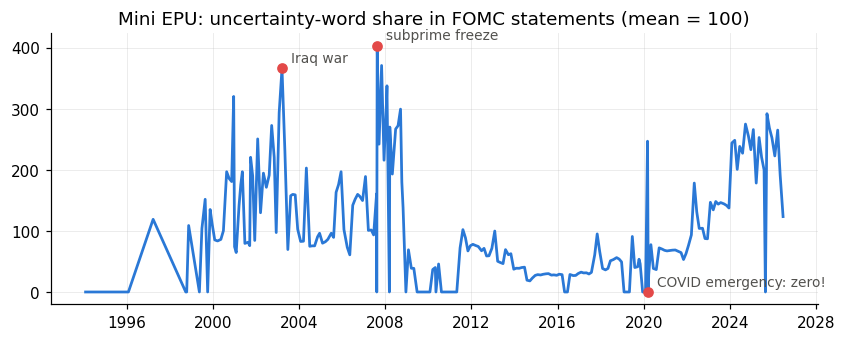

five most uncertainty-heavy statements:
2007-08-17    403.0
2007-10-31    371.0
2003-03-18    366.0
2008-01-30    337.0
2000-12-19    320.0

and the March 2020 emergency statement? index = 0


In [10]:
UNCERTAINTY_WORDS = {"uncertain", "uncertainty", "uncertainties", "risk", "risks",
                     "volatility", "strains", "stress", "turmoil", "disruptions"}

u = np.array([sum(tok in UNCERTAINTY_WORDS for tok in toks) / len(toks) for toks in docs_tokens])
epu = 100 * u / u.mean()
ts = pd.Series(epu, index=pd.to_datetime(dates), name="uncertainty index")

fig, ax = plt.subplots()
ax.plot(ts.index, ts.values, color=BLUE)
ax.set_title("Mini EPU: uncertainty-word share in FOMC statements (mean = 100)")
for label, when in [("Iraq war", "2003-03-18"), ("subprime freeze", "2007-08-17"),
                    ("COVID emergency: zero!", "2020-03-15")]:
    if when in ts.index:
        ax.annotate(label, (pd.Timestamp(when), ts[when]), textcoords="offset points",
                    xytext=(6, 4), fontsize=9, color=GRAY)
        ax.plot(pd.Timestamp(when), ts[when], "o", ms=6, color=RED)
plt.show()

print("five most uncertainty-heavy statements:")
print(ts.sort_values(ascending=False).head(5).round(0).to_string())
print(f"\nand the March 2020 emergency statement? index = {ts['2020-03-15']:.0f}")

A ten-word dictionary and a divide — and the series finds the Iraq-war meeting, the August 2007 subprime freeze, and the 2008 crisis on its own. That transparency (you can audit every count) is the argument for dictionaries.

But look at the annotation on the right: the **March 15, 2020 emergency statement scores exactly zero**. The single most uncertain moment in the sample announces rate cuts to zero and \$700bn of QE — in confident, decisive language, with not one word from our dictionary. **A dictionary counts words, not situations.** That blind spot — negation, context, novel vocabulary, tone — is exactly why the lecture moves from counting to *learned* representations, our next stop.

---

## Part 4 — Word embeddings from co-occurrence

**You are here:** tokenize → count → `EMBED`

Bag-of-Words has a geometric flaw the lecture keeps hammering: every word is its own perpendicular axis, so *unemployment* ⟂ *joblessness*. The fix is a learned map

$$E:\; \{1,\dots,M\} \;\to\; \mathbb{R}^d$$

placing words with similar *contexts* at nearby points — the **distributional hypothesis** ("you shall know a word by the company it keeps", Firth 1957).

**How we'll learn it here.** Word2Vec (T2b) learns $E$ by SGD on a prediction task. On a corpus our size there's a classical equivalent that is deterministic and runs in seconds: build the word–context **co-occurrence matrix**, reweight it with **PPMI** (positive pointwise mutual information), and factor it with **SVD**. Levy & Goldberg (2014) showed skip-gram with negative sampling implicitly factorizes almost exactly this matrix — so this *is* word2vec's count-based twin:

$$\mathrm{PPMI}(w,c) = \max\!\left(0,\; \log\frac{P(w,c)}{P(w)P(c)}\right), \qquad X_{\mathrm{PPMI}} \approx U \Sigma V^\top, \qquad E = U_{[:,:d]} \,\Sigma_{[:d]}^{1/2}$$

In [11]:
WINDOW, MIN_COUNT, D_EMB = 5, 10, 100

emb_vocab = [w for w, c in word_counts.most_common() if c >= MIN_COUNT]
w2i = {w: i for i, w in enumerate(emb_vocab)}
V_emb = len(emb_vocab)
print(f"embedding vocabulary: {V_emb:,} words (count >= {MIN_COUNT}), window ±{WINDOW}, d = {D_EMB}")

# co-occurrence counts within a ±WINDOW word window
cooc = np.zeros((V_emb, V_emb))
for toks in docs_tokens:
    ids = [w2i[t] for t in toks if t in w2i]
    for pos, wi in enumerate(ids):
        for ctx in ids[max(0, pos - WINDOW): pos] + ids[pos + 1: pos + 1 + WINDOW]:
            cooc[wi, ctx] += 1

# PPMI reweighting
total = cooc.sum()
p_w = cooc.sum(axis=1) / total
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((cooc / total) / np.outer(p_w, p_w))
ppmi = np.where(np.isfinite(pmi) & (pmi > 0), pmi, 0.0)

# SVD -> dense vectors
U, S, _ = np.linalg.svd(ppmi, full_matrices=False)
E_vec = U[:, :D_EMB] * np.sqrt(S[:D_EMB])
E_vec /= np.linalg.norm(E_vec, axis=1, keepdims=True)          # unit rows: dot = cosine
print("embedding matrix:", E_vec.shape)

embedding vocabulary: 831 words (count >= 10), window ±5, d = 100


embedding matrix: (831, 100)


In [12]:
def neighbors(word, k=8):
    sims = E_vec @ E_vec[w2i[word]]
    return [(emb_vocab[j], round(float(sims[j]), 2))
            for j in np.argsort(sims)[::-1][1: k + 1]]

for w in ["inflation", "employment", "committee"]:
    print(f"{w:>12s}: {neighbors(w)}")

   inflation: [('expectations', 0.51), ('2', 0.5), ('relative', 0.44), ('percent', 0.43), ('symmetric', 0.42), ('and', 0.41), ('based', 0.4), ('low', 0.4)]
  employment: [('maximum', 0.93), ('promoting', 0.67), ('returning', 0.66), ('objectives', 0.65), ('seeks', 0.64), ('symmetric', 0.59), ('achieve', 0.58), ('relative', 0.54)]
   committee: [('the', 0.52), ('open', 0.52), ('decided', 0.51), ('to', 0.48), ('today', 0.48), ('its', 0.47), ('particular', 0.47), ('met', 0.42)]


*Unemployment* and *joblessness* are no longer perpendicular — words that appear in the same monetary-policy contexts have landed near each other, learned from counts alone.

### Step 2 — Analogies, honestly

The famous result is $u_{king} - u_{man} + u_{woman} \approx u_{queen}$ — but that was trained on 100B general-domain words. Our corpus is ~1 MB of formal committee prose: no kings, no queens. What a *domain* corpus **can** support is domain regularities, e.g. verb morphology it has seen many times. (Fun fact you can verify with `word_counts`: FOMC statements *never* contain "raised" or "lowered" — the Committee always "decided to raise". Word choice is institutional.) We try `increase : increased :: strengthen : ?` and report the top-5 candidates honestly — and you should try a few of your own and watch most of them fail; that is the honest experience of analogies on a small corpus.

In [13]:
def analogy(a, b, c, k=5):
    """b - a + c -> nearest words (excluding the inputs)."""
    v = E_vec[w2i[b]] - E_vec[w2i[a]] + E_vec[w2i[c]]
    v /= np.linalg.norm(v)
    sims = E_vec @ v
    out = [(emb_vocab[j], round(float(sims[j]), 2)) for j in np.argsort(sims)[::-1]
           if emb_vocab[j] not in {a, b, c}]
    return out[:k]

print("increase : increased :: strengthen : ?")
print(analogy("increase", "increased", "strengthen"))

increase : increased :: strengthen : ?
[('strengthened', 0.51), ('sectors', 0.39), ('most', 0.38), ('affected', 0.37), ('adversely', 0.33)]


### Step 3 — A hawk–dove direction

The T2b slides propose measuring policy *stance* with a direction in embedding space: $\hat{v} = u_{hike} - u_{cut}$. In formal FOMC prose the words *hike*/*cut* themselves are rare, so we average small synonym sets (and print the counts, so you can see why):

$$\hat{v} \;=\; \mathrm{mean}(u_{raise}, u_{increase}, u_{tighten}, \dots) \;-\; \mathrm{mean}(u_{lower}, u_{cut}, u_{ease}, \dots)$$

Each statement is scored by the cosine between $\hat{v}$ and its **TF-IDF-weighted mean word vector** (TF-IDF weighting from Part 2 keeps boilerplate from dominating — the parts of this lab compose).

And then — this is the important half of the exercise — we **validate** it against ground truth we happen to have: the Fed's actual hiking and cutting cycles.

hawkish seeds in vocab: {'raise': 60, 'increase': 80, 'increased': 34, 'increasing': 24, 'tightening': 15, 'firming': 32}
dovish  seeds in vocab: {'lower': 83, 'easing': 21, 'eased': 16, 'accommodative': 159, 'accommodation': 89}


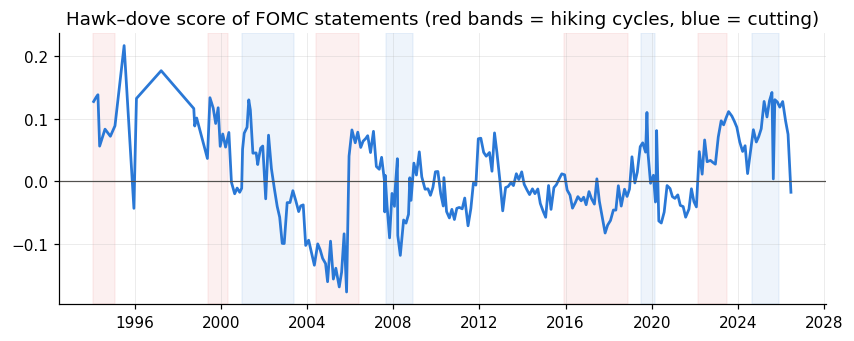

mean score inside hiking bands : +0.029
mean score inside cutting bands: +0.028
gap: +0.001   <- a stance measure needs this to be clearly > 0

worst case, the 2004-06 hiking cycle: -0.074  (dovish?!)


In [14]:
HAWK_SEEDS = ["raise", "increase", "increased", "increasing", "tightening", "firming"]
DOVE_SEEDS = ["lower", "easing", "eased", "accommodative", "accommodation"]

hawk = [w for w in HAWK_SEEDS if w in w2i]
dove = [w for w in DOVE_SEEDS if w in w2i]
print("hawkish seeds in vocab:", {w: word_counts[w] for w in hawk})
print("dovish  seeds in vocab:", {w: word_counts[w] for w in dove})

v_hat = E_vec[[w2i[w] for w in hawk]].mean(axis=0) - E_vec[[w2i[w] for w in dove]].mean(axis=0)
v_hat /= np.linalg.norm(v_hat)

def doc_vector(i):
    """TF-IDF-weighted mean embedding of statement i."""
    vec, weight = np.zeros(D_EMB), 0.0
    for w in set(docs_tokens[i]):
        if w in w2i and w in w2col:
            tfidf = X[i, w2col[w]]
            vec += tfidf * E_vec[w2i[w]]
            weight += tfidf
    return vec / weight

score = np.array([cosine(doc_vector(i), v_hat) for i in range(N)])
hd = pd.Series(score, index=pd.to_datetime(dates), name="hawk-dove score")

HIKING  = [("1994-02", "1995-02"), ("1999-06", "2000-05"), ("2004-06", "2006-06"),
           ("2015-12", "2018-12"), ("2022-03", "2023-07")]
CUTTING = [("2001-01", "2003-06"), ("2007-09", "2008-12"), ("2019-07", "2020-03"), ("2024-09", "2025-12")]

fig, ax = plt.subplots()
ax.plot(hd.index, hd.values, color=BLUE)
for lo, hi in HIKING:
    ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color=RED, alpha=0.08)
for lo, hi in CUTTING:
    ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color=BLUE, alpha=0.08)
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_title("Hawk–dove score of FOMC statements (red bands = hiking cycles, blue = cutting)")
plt.show()

# validation: does the score actually separate hiking from cutting periods?
hike_mean = np.mean([hd[lo:hi].mean() for lo, hi in HIKING])
cut_mean = np.mean([hd[lo:hi].mean() for lo, hi in CUTTING])
print(f"mean score inside hiking bands : {hike_mean:+.3f}")
print(f"mean score inside cutting bands: {cut_mean:+.3f}")
print(f"gap: {hike_mean - cut_mean:+.3f}   <- a stance measure needs this to be clearly > 0")
print(f"\nworst case, the 2004-06 hiking cycle: {hd['2004-06':'2006-06'].mean():+.3f}  (dovish?!)")

**The validation fails.** The gap between hiking and cutting bands is ≈ 0, and the 2004–06 hiking cycle — seventeen consecutive rate *increases* — scores as the most *dovish* stretch in the sample. Why? Open a 2005 statement and read it: every one says policy *"remains **accommodative**"* and discusses *"removing policy **accommodation** at a measured pace."* Our dove seeds appear most densely **exactly while the Fed is hiking**, because the Committee is describing the accommodation it is removing. A static word vector cannot see that "removing accommodation" points the *opposite* way from "accommodation."

This is not a bug in your code — it is the lecture's central caution playing out on real data (T5b's six-step workflow: **validate before you regress**; T2b's limit: one vector per word, no context, no negation, no direction). If you had skipped the bands and regressed bond yields on this score, you would have gotten a coefficient, a t-statistic, and a wrong paper.

### ✏️ Your turn — A3: beat 100 dimensions with a regex

Here is the twist: for *this* construct, the transparent tool wins. The Fed announces its decision in one formulaic sentence — *"decided to **raise** the target range…"*, *"**ease** the degree of pressure on reserve positions"* (1990s wording). So count decisions directly:

1. Build two regexes: hawkish verbs (*raise, increase, firm, tighten…*) and dovish verbs (*lower, reduce, cut, ease…*), each within a few words **before** "target", "federal funds rate", or "pressure on reserve".
2. Score each statement `hawk_matches − dove_matches`; plot with the same bands; recompute the two band means.

You should find what the embedding could not deliver: every hiking band positive, every cutting band negative. Moral (the lecture's thesis, live): **identification precedes measurement** — knowing *where the signal lives* beats a fancier representation of the whole document. *(Solution in the Appendix.)*

In [15]:
# ✏️ A3 — your code here
# HAWK_PAT = re.compile(...)
# DOVE_PAT = re.compile(...)
# decision_score = ...


---

## Part 5 — How much did the statement change?

Traders famously read each FOMC statement *as a diff against the previous one* — a few changed words move markets. We can measure exactly that with tools already on the table: the change series

$$\delta_t \;=\; 1 - \cos\!\big(\text{TF-IDF}(D_{t-1}),\; \text{TF-IDF}(D_t)\big)$$

$\delta_t \approx 0$: this statement is a copy-edit of the last one. Large $\delta_t$: the Committee changed what it is talking about.

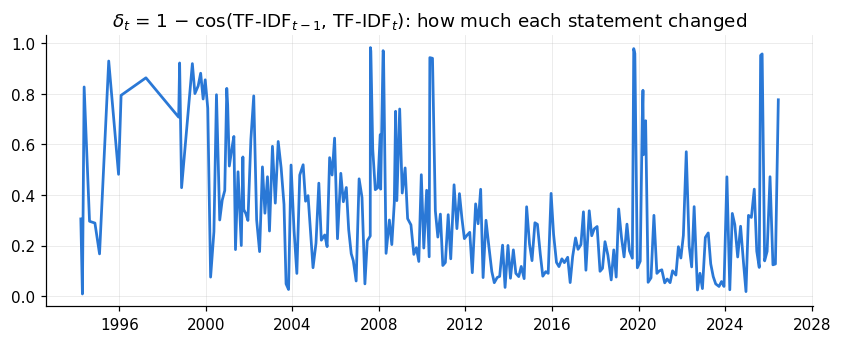

eight largest statement-to-statement changes:
2007-08-10    0.983
2019-10-11    0.979
2008-03-11    0.971
2007-08-17    0.969
2008-03-18    0.964
2019-10-30    0.960
2025-09-17    0.958
2025-08-22    0.953


In [16]:
delta = np.array([1 - cosine(X[i - 1], X[i]) for i in range(1, N)])
dl = pd.Series(delta, index=pd.to_datetime(dates[1:]), name="delta")

fig, ax = plt.subplots()
ax.plot(dl.index, dl.values, color=BLUE)
ax.set_title(r"$\delta_t$ = 1 − cos(TF-IDF$_{t-1}$, TF-IDF$_t$): how much each statement changed")
plt.show()

print("eight largest statement-to-statement changes:")
print(dl.sort_values(ascending=False).head(8).round(3).to_string())

The top of the list reads like a monetary-policy history exam — but not the one you'd expect. The August 2007 subprime freeze and March 2008 (Bear Stearns week) are there, and so are the corpus's **special statements**: the October 2019 reserve-management announcement and the August 2025 framework-review update, each a complete change of subject from the statement before it. One line of linear algebra over word counts recovers "the moments the Fed changed its message" — and forces you to *look at your documents* to understand why. (Both lessons are real.)

---

### Make it your own

- **Swap the dictionary** (Part 3): build a *dovish-language* index, or import terms from the Loughran–McDonald finance dictionary and score negativity.
- **Bigrams** (Part 2): rebuild TF-IDF on bigrams so *not_sufficient* survives as one feature — the lecture's negation thinkbox, live.
- **Embedding δ** (Part 5): recompute $\delta_t$ with the TF-IDF-weighted mean *embedding* vectors from Part 4 — does meaning-space see changes that word-space misses?

### Wrap-up — the whole lab in one map

| You built | The idea | Where it breaks |
|---|---|---|
| tokenizer + BPE | text → integer IDs; subwords kill OOV | boundaries are a modeling choice |
| BoW / TF-IDF | documents as sparse count vectors | word order gone; synonyms perpendicular |
| dictionary index | transparent, auditable measurement | misses negation, context, novelty |
| PPMI+SVD embeddings | meaning from co-occurrence geometry | one vector per word — *interest* (rate) = *interest* (hobby) |
| hawk–dove / $\delta_t$ | text features you can put in a regression | validate before you regress (T5b) |

**Bridge to Lab 7B:** every representation here treats a document as a *bag*. But "growth is **not** sufficient" ≠ "growth is sufficient" — order and context carry the signal counting throws away. The mechanism that reads order and context is **attention**, and it's the star of the next notebook.

---

## Appendix — Reference solutions

In [17]:
# A1 — subwords never fall out of vocabulary
word = "reflationary"
print(f'"{word}" in word-level vocab: {word in vocab}')          # False -> OOV, dropped
pieces = bpe_segment(word, merges)
print(f"BPE segmentation ({len(pieces)} tokens): {pieces}")
# Every piece was learned from the corpus, so the model still gets a usable
# representation of a word it has never seen — that is the whole point of subwords.

"reflationary" in word-level vocab: False
BPE segmentation (6 tokens): ['re', 'f', 'la', 'tion', 'ar', 'y</w>']


In [18]:
# A2 — what TF-IDF does to similarity
c1, c2 = toy_counts.loc["doc 1"].values.astype(float), toy_counts.loc["doc 2"].values.astype(float)
print(f"cosine on raw counts : {cosine(c1, c2):.2f}")

toy_df = (toy_counts > 0).sum(axis=0).values                     # docs containing each word
toy_idf = np.log(2 / toy_df)                                     # N = 2
t1, t2 = c1 / c1.sum() * toy_idf, c2 / c2.sum() * toy_idf
print(f"cosine on TF-IDF     : {cosine(t1, t2):.2f}")
# central/bank/rates appear in BOTH docs -> IDF = log(2/2) = 0 -> those axes vanish.
# What remains is each doc's distinctive vocabulary (cuts/support/growth vs
# raises/curb/inflation) — disjoint, so similarity drops to 0. TF-IDF just bought
# a retrieval system the ability to ignore shared boilerplate and match on content.

cosine on raw counts : 0.50
cosine on TF-IDF     : 0.00


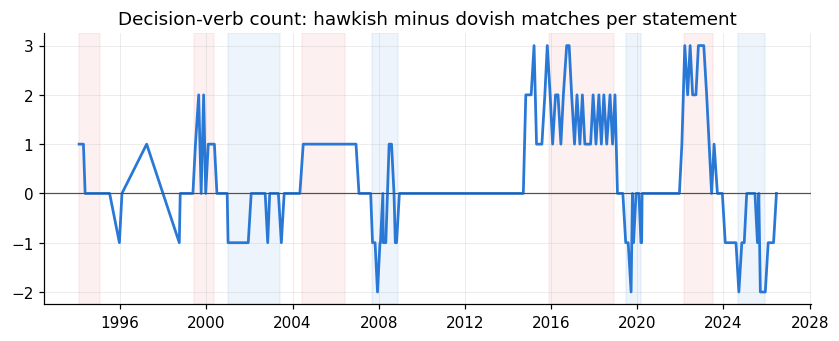

mean inside hiking bands : +1.23
mean inside cutting bands: -0.68


In [19]:
# A3 — beat 100 dimensions with a regex
HAWK_PAT = re.compile(
    r"\b(raise|raising|increase|increasing|firm|firming|tighten)\w*\W+(?:\w+\W+){0,6}?"
    r"(target|federal funds rate|pressure on reserve)", re.I)
DOVE_PAT = re.compile(
    r"\b(lower|lowering|reduce|reducing|cut|cutting|ease|easing|decrease)\w*\W+(?:\w+\W+){0,6}?"
    r"(target|federal funds rate|pressure on reserve)", re.I)

decision = [len(HAWK_PAT.findall(t)) - len(DOVE_PAT.findall(t)) for _, t in statements]
ds = pd.Series(decision, index=pd.to_datetime(dates), name="decision count")

fig, ax = plt.subplots()
ax.plot(ds.index, ds.values, color=BLUE)
for lo, hi in HIKING:
    ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color=RED, alpha=0.08)
for lo, hi in CUTTING:
    ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color=BLUE, alpha=0.08)
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_title("Decision-verb count: hawkish minus dovish matches per statement")
plt.show()

hike_mean = np.mean([ds[lo:hi].mean() for lo, hi in HIKING])
cut_mean = np.mean([ds[lo:hi].mean() for lo, hi in CUTTING])
print(f"mean inside hiking bands : {hike_mean:+.2f}")
print(f"mean inside cutting bands: {cut_mean:+.2f}")
# Every hiking band positive, every cutting band negative — the ten-line regex
# recovers the stance that the 100-dimensional embedding score could not, because
# it looks exactly where the signal lives: the decision sentence. Identification
# precedes measurement. (And when the object of interest ISN'T announced in a
# formulaic sentence — tone, urgency, implicit risk — you need the contextual
# models of Lab 7B. Match the tool to the object.)